In [3]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 26.0 MB/s  0:00:00 eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]━━━━ 1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os
os.getcwd()

'/Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis'

In [23]:
LOGS_DIR = os.getcwd() + "/../logs/full/"
LOGS_DIR

'/Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../logs/full/'

In [20]:
files = sorted(Path(LOGS_DIR).glob("*.csv"))
data = [pd.read_csv(f) for f in files]
names = [f.stem for f in files]

In [16]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2,
})

# optional LaTeX (if installed)
plt.rcParams["text.usetex"] = True

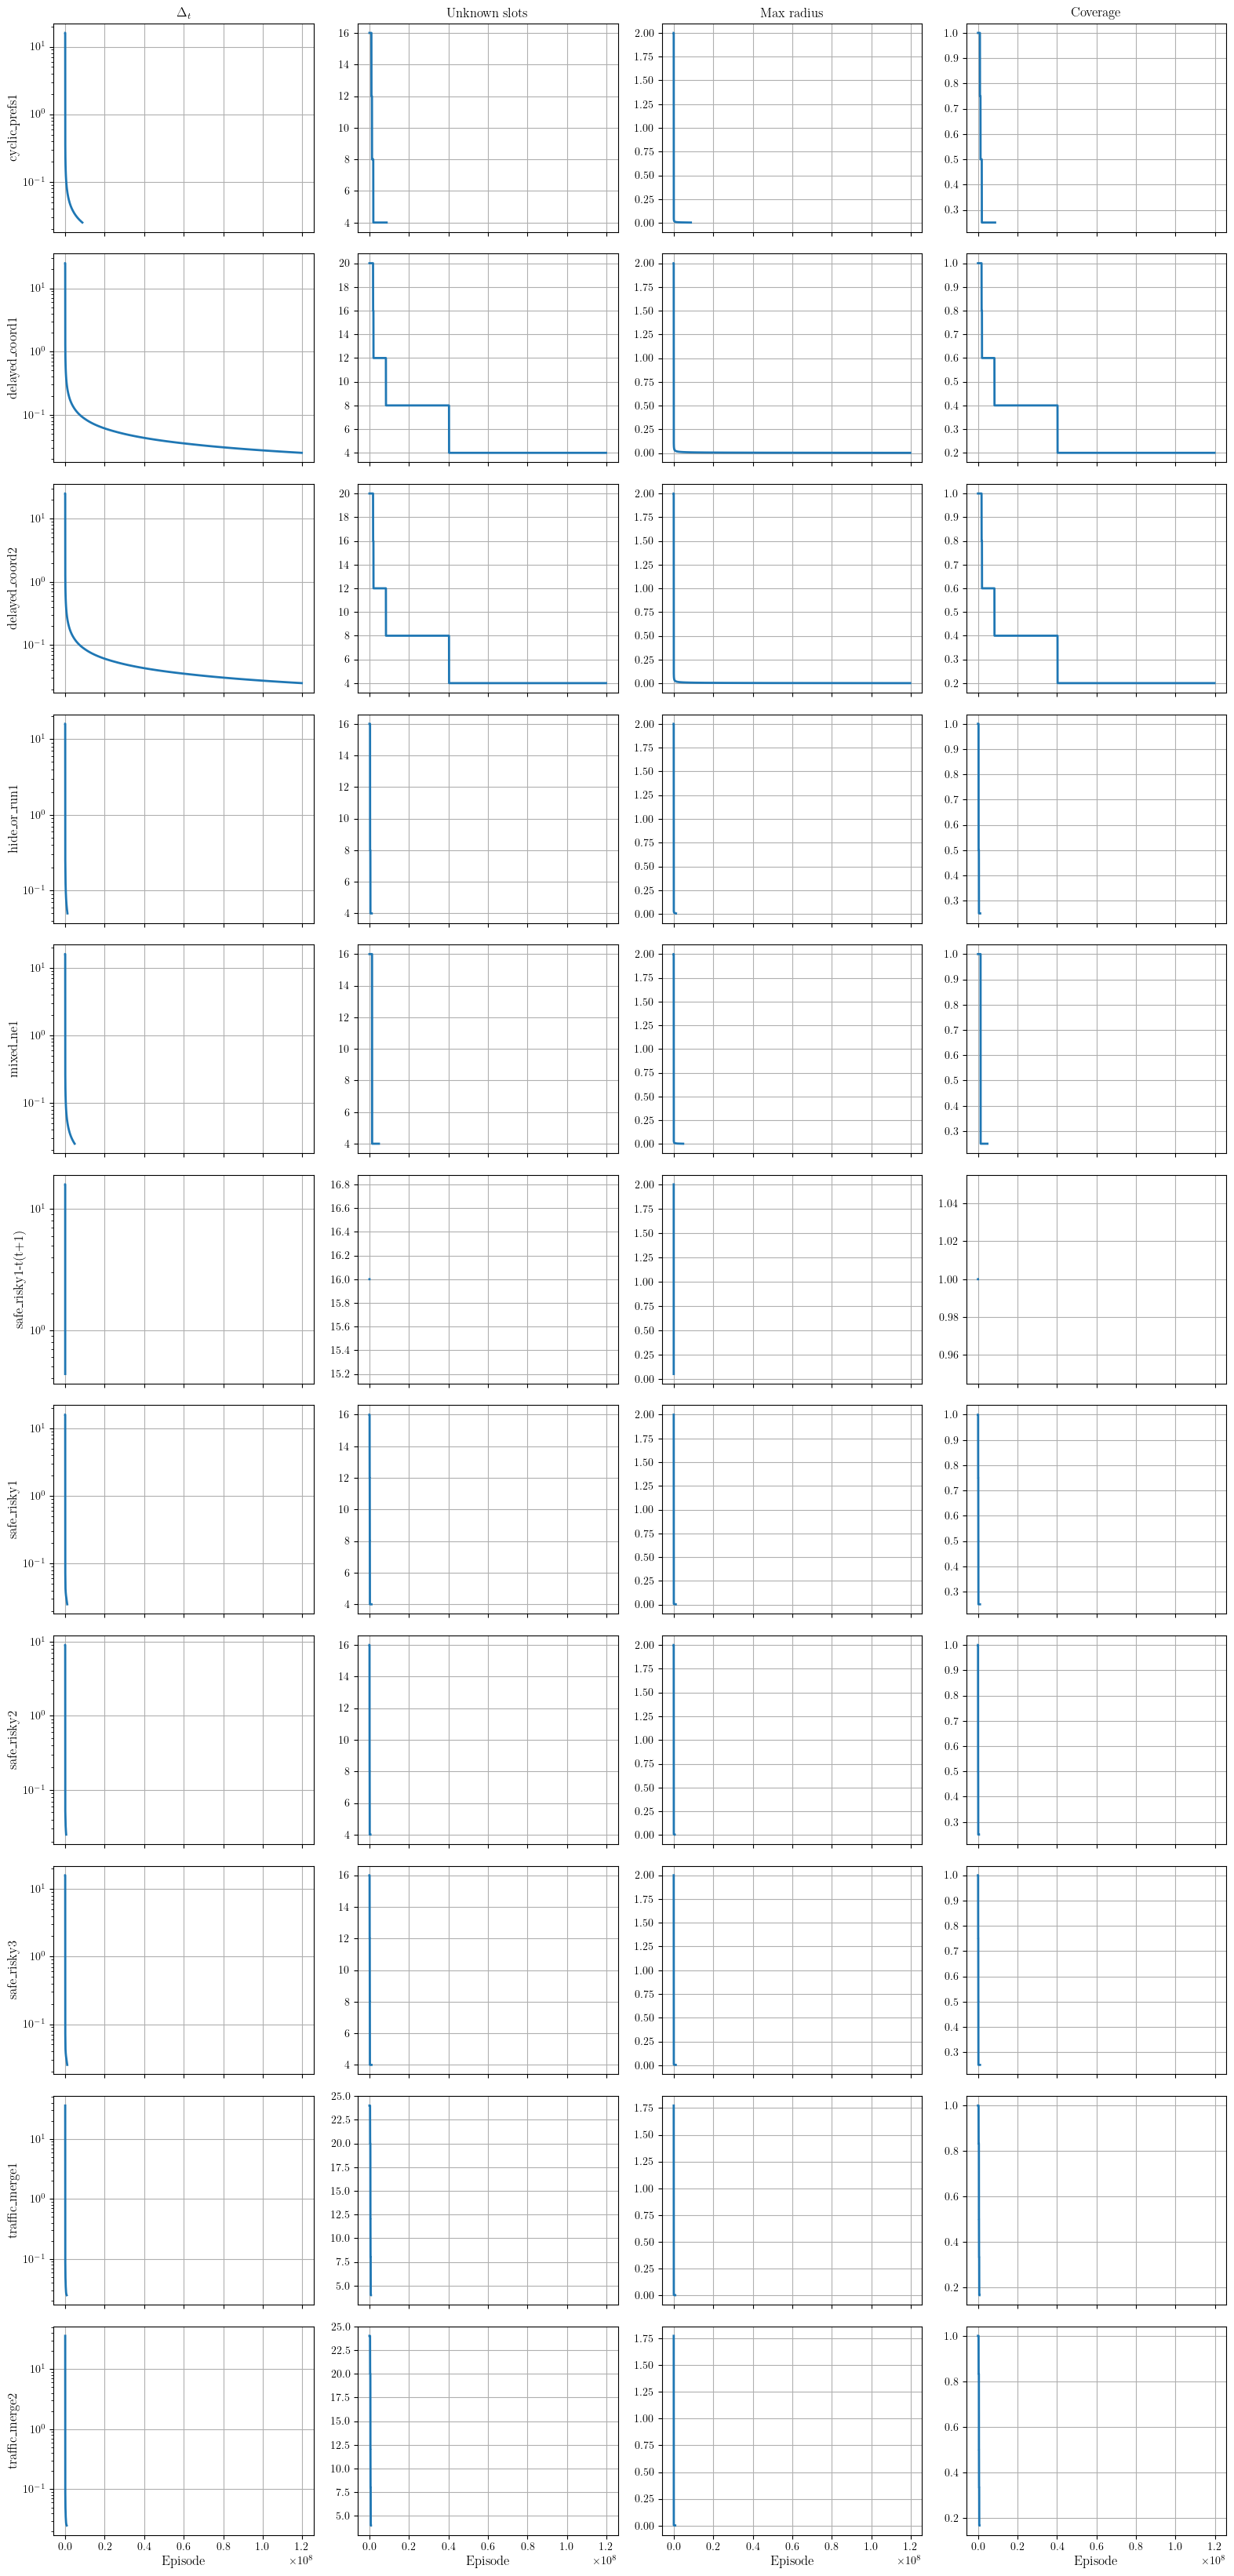

In [17]:
metrics = [
    ("deltaT", r"$\Delta_t$"),
    ("maxRadius", "Max radius"),
    ("coverage", "Coverage"),
]

num_rows = len(data)
num_cols = len(metrics)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(4*num_cols, 3*num_rows), sharex=True)

if num_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i, df in enumerate(data):
    for j, (col, label) in enumerate(metrics):
        ax = axes[i, j]

        ax.plot(df["episode"], df[col])

        if col == "deltaT":
            ax.set_yscale("log")

        if i == 0:
            ax.set_title(label)

        if j == 0:
            ax.set_ylabel(names[i])

        if i == num_rows - 1:
            ax.set_xlabel("Episode")

        ax.grid(True)

plt.tight_layout()
plt.show()

## Selecting delayed_coord2 for main RQ1a

In [31]:
files = list(Path(LOGS_DIR).glob("delayed_coord2.csv"))
delayed_coord2 = pd.read_csv(files[0])
df = pd.read_csv(LOGS_DIR + "safe_risky3.csv")

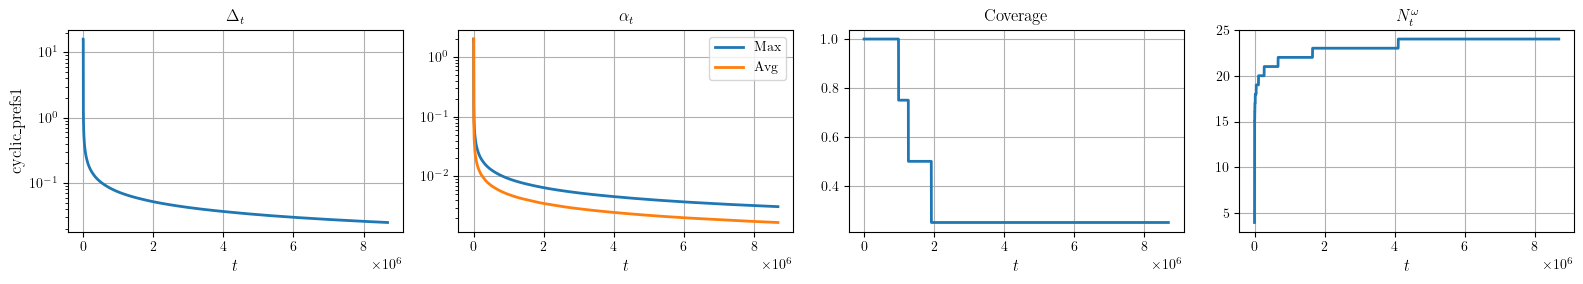

<Figure size 640x480 with 0 Axes>

In [36]:
metrics = [
    ("deltaT", r"$\Delta_t$"),
    ("radius", r"$\alpha_t$"),
    ("coverage", "Coverage"),
    ("numSamples", r"$N^\omega_t$")
]

fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3), sharex=True)

for j, (col, label) in enumerate(metrics):
    ax = axes[j]
    df = data[0]

    if col == "radius":
        ax.plot(df["episode"], df["maxRadius"], label="Max")
        ax.plot(df["episode"], df["avgRadius"], label="Avg")
        ax.legend()
    else:
        ax.plot(df["episode"], df[col])

    if col == "deltaT" or col == "radius":
        ax.set_yscale("log")

    ax.set_title(label)
    ax.set_xlabel("$t$")
    if j == 0:
        ax.set_ylabel(names[0])

    ax.grid(True)

plt.tight_layout()
plt.show()
plt.savefig(
    "delayed_coord2_learning.pdf",
    bbox_inches="tight",
    dpi=300
)